# DECO6500 · A2 Quantitative First Pass
**Version 1.1 · September 2026 · DECO6500 Advanced Human-Computer Interaction, UQ**

## ⚠️ Before you do anything else: **File → Save a copy in Drive**

You are looking at the course's master copy. You cannot save changes to it, and anything you type here disappears when the session ends. Save your own copy first (or click **Copy to Drive** in the toolbar), then work in that copy. Do this every time you open the notebook from the course link.\n\nCourse link to this notebook: https://colab.research.google.com/github/petewnr/DECO6500-A2-Quantitative/blob/main/DECO6500_A2_Quantitative_First_Pass.ipynb

## What may go into this notebook
Only **de-identified quantitative data**: participant IDs (P01, P02 …), demographics and psychographics, task outcomes, times, error counts, questionnaire scores. **Never** names, contact details, recordings, or transcripts. Transcripts go into NVivo through the UQ Digital Workspace. If you are unsure whether a column is identifying, leave it out. The master copy of your data stays in your Team SharePoint folder; this notebook works on an upload that is deleted when the session closes.

## What this notebook does
It takes one CSV — one row per participant — and produces the things the Week 7 lecture described: counts before percentages, medians and ranges, dot plots that show every value, SUS and NASA-TLX scoring, a scatterplot with Spearman and Pearson for **association**, and a two-group comparison with Mann–Whitney or Fisher's exact for **difference**. You do not need to write Python. You tell it your column names once (Section 3), edit the short lists marked **✏️ EDIT**, and run the cells in order (▶ on the left of each cell, or Shift+Enter).

## What it will not do for you
It will not tell you what a number means for your committed questions. Every output here is a description of your sixteen to twenty participants, and the register is **suggests**. Decide *before* you run Sections 8 and 9 which two or three associations or comparisons your committed questions care about, write them in the 'decided in advance' cells, and report those — including the ones that show nothing.

## The notes cells are the point
After each analysis step there is a **📝 Analysis notes** cell. Double-click it and write what you see, in sentences, while it is in front of you. Those notes — not the charts — are what goes into your research notebook and the report, and they are what a tutor will read on Friday. A notebook full of outputs and empty notes cells is a notebook where no analysis has happened.

## 1 · Setup — run this cell once
Loads the libraries and defines the helper functions the rest of the notebook uses. Nothing to edit.

In [18]:
import io, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

NAVY, TEAL, AMBER, GREY = "#1F3A5F", "#0E7C86", "#C8961E", "#888888"

def _say(msg):
    print(textwrap.fill(msg, 100))

def count_table(df, column, order=None):
    """Counts with n and percentage beside — never a percentage alone."""
    s = df[column].dropna()
    vc = s.value_counts()
    if order:
        vc = vc.reindex([o for o in order if o in vc.index]).fillna(0).astype(int)
    out = pd.DataFrame({"count": vc, "of_n": len(s)})
    out["percent"] = (100 * out["count"] / out["of_n"]).round(0).astype(int)
    out["report_as"] = [f"{c} of {n} ({p}%)" for c, n, p in zip(out["count"], out["of_n"], out["percent"])]
    return out

def summarise(df, column, label=None):
    """Median, range, mean, SD, n — for one numeric column."""
    s = pd.to_numeric(df[column], errors="coerce").dropna()
    label = label or column
    return pd.Series({
        "n": int(s.size),
        "median": round(float(s.median()), 1),
        "min": float(s.min()), "max": float(s.max()),
        "mean": round(float(s.mean()), 1), "sd": round(float(s.std(ddof=1)), 1) if s.size > 1 else np.nan,
    }, name=label)

def dot_plot(df, column, by=None, title=None, ylabel=None):
    """Every value shown as a dot. One column, or one column per group. Median marked."""
    fig, ax = plt.subplots(figsize=(4.5 if by is None else 5.5, 3.6))
    if by is None:
        groups = [(column, pd.to_numeric(df[column], errors="coerce").dropna())]
    else:
        groups = [(str(g), pd.to_numeric(sub[column], errors="coerce").dropna()) for g, sub in df.groupby(by, sort=True)]
    rng = np.random.default_rng(0)
    for i, (g, vals) in enumerate(groups):
        x = i + rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(x, vals, s=36, color=TEAL, alpha=0.8, zorder=3)
        if len(vals):
            ax.hlines(vals.median(), i - 0.22, i + 0.22, color=NAVY, linewidth=2.5, zorder=4)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([f"{g}\n(n={len(v)})" for g, v in groups])
    ax.set_ylabel(ylabel or column)
    ax.set_title(title or f"{column} — every participant, median marked", fontsize=10, color=NAVY)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout(); plt.show()

def sus_scores(df, prefix="sus_"):
    """Standard SUS: odd items score (x-1), even items (5-x), sum × 2.5 → 0–100."""
    cols = [f"{prefix}{i}" for i in range(1, 11)]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"SUS needs columns {cols}; missing {missing}")
    items = df[cols].apply(pd.to_numeric, errors="coerce")
    odd = items[[f"{prefix}{i}" for i in (1, 3, 5, 7, 9)]].sub(1).sum(axis=1)
    even = (5 - items[[f"{prefix}{i}" for i in (2, 4, 6, 8, 10)]]).sum(axis=1)
    return (odd + even) * 2.5

def tlx_raw(df, prefix="tlx_"):
    """Raw NASA-TLX: unweighted mean of the six 0–100 sub-scales."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    if len(cols) != 6:
        raise KeyError(f"Raw TLX needs six columns starting '{prefix}'; found {cols}")
    return df[cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

def associate(df, x, y, label_x=None, label_y=None):
    """Scatterplot first; then Spearman (default) and Pearson, with n. Association, not cause."""
    d = df[[x, y]].apply(pd.to_numeric, errors="coerce").dropna()
    n = len(d)
    if n < 8:
        _say(f"Only {n} participants have both {x} and {y}. Show the scatterplot, but do not report a coefficient from fewer than 8.");
    rho, p_rho = stats.spearmanr(d[x], d[y])
    r, p_r = stats.pearsonr(d[x], d[y]) if n > 2 else (np.nan, np.nan)
    fig, ax = plt.subplots(figsize=(4.8, 3.8))
    rng = np.random.default_rng(0)
    jitter = rng.uniform(-0.06, 0.06, size=n) if d[x].nunique() <= 7 else 0
    ax.scatter(d[x] + jitter, d[y], s=40, color=TEAL, alpha=0.85, zorder=3)
    ax.set_xlabel(label_x or x); ax.set_ylabel(label_y or y)
    ax.set_title(f"{label_y or y} against {label_x or x}  (n = {n})", fontsize=10, color=NAVY)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()
    t_crit = stats.t.ppf(0.975, n - 2); r_crit = t_crit / np.sqrt(t_crit**2 + n - 2)
    size = "weak" if abs(rho) < 0.3 else "moderate" if abs(rho) < 0.5 else "strong"
    direction = "positive" if rho > 0 else "negative"
    print(f"Spearman ρ = {rho:.2f}, p = {p_rho:.3f}, n = {n}   ← report this one by default")
    print(f"Pearson  r = {r:.2f}, p = {p_r:.3f}, n = {n}   ← only for two continuous, roughly normal measures")
    print()
    _say(f"Read: a {size} {direction} association in these {n} participants. "
         + ("Would conventionally be called statistically significant (p < .05) — but look at the plot: at this n one or two participants can make the line. "
            if p_rho < 0.05 else
            f"Would not conventionally be called statistically significant. That is a reportable result, not a failure: with n = {n} a correlation needs to be about {r_crit:.2f} or larger before p < .05. ")
         + "Report ρ, n and p together. Association is not cause. Write the sentence in the 'suggests' register and point to the interviews for why.")
    if abs(r - rho) > 0.10:
        _say("Note: Pearson and Spearman disagree by more than 0.1 — usually one or two extreme values are pulling Pearson. The scatterplot will show which. Report Spearman and say so.")

def compare(df, outcome, group, label=None, success_value=None):
    """Two groups only. Descriptives and dot plot first; then Mann–Whitney (measure) or Fisher's exact (yes/no)."""
    d = df[[outcome, group]].dropna()
    levels = sorted(d[group].astype(str).unique())
    if len(levels) != 2:
        _say(f"'{group}' has {len(levels)} levels ({levels}). This notebook compares two groups only. "
             "Collapse to two if there is a sensible way, or report descriptives only. Three groups of six is too thin."); return
    sizes = d[group].astype(str).value_counts()
    if sizes.min() < 5:
        _say(f"Warning: the smaller group has only {sizes.min()} participants. Report the descriptives and the plot; treat any test as exploratory at best.")
    numeric = pd.to_numeric(d[outcome], errors="coerce")
    is_measure = numeric.notna().all() and d[outcome].nunique() > 2
    if is_measure:
        d = d.assign(**{outcome: numeric})
        desc = d.groupby(group)[outcome].agg(n="size", median="median", min="min", max="max").round(1)
        print(desc.to_string()); print()
        dot_plot(d, outcome, by=group, title=f"{label or outcome} by {group}")
        a = d.loc[d[group].astype(str) == levels[0], outcome]; b = d.loc[d[group].astype(str) == levels[1], outcome]
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"Difference in medians: {a.median():.1f} ({levels[0]}, n={len(a)}) vs {b.median():.1f} ({levels[1]}, n={len(b)})")
        print(f"Mann–Whitney U = {u:.1f}, p = {p:.3f}")
        print()
        if p < 0.05:
            _say("Read: a difference this size would be unusual by chance in groups this small — 'suggests', not 'demonstrates'. The groups may differ on other things too (check the demographics), and the sample is a convenience one. Report the medians, the n, U and p together; point to the interviews for why.")
        else:
            _say("Read: there IS an observed difference (say what it is, with the n). The test cannot distinguish it from chance in groups this small — that is 'no statistically significant difference', which is honest. It is NOT 'no difference' and NOT 'the groups performed the same'. Say the study was too small to detect anything but a large effect.")
    else:
        if success_value is None:
            _say(f"'{outcome}' looks like a category. Pass success_value=... (for example success_value='unaided') to compare the count of that outcome between the two groups."); return
        d = d.assign(hit=(d[outcome].astype(str) == str(success_value)))
        ct = pd.crosstab(d[group], d["hit"]).reindex(columns=[True, False], fill_value=0)
        ct.columns = [f"{success_value}", f"not {success_value}"]
        ct["report_as"] = [f"{r.iloc[0]} of {r.iloc[0] + r.iloc[1]}" for _, r in ct.iterrows()]
        print(ct.to_string()); print()
        odds, p = stats.fisher_exact(ct.iloc[:, :2].values)
        print(f"Fisher's exact test: p = {p:.3f}   (chi-square is not appropriate at counts this small)")
        print()
        _say("Read: report the two counts with their n first; the test second. " + (
            "A split this uneven would be unusual by chance — 'suggests'." if p < 0.05 else
            "The test cannot distinguish this from chance in groups this small; say what you observed and that the study was too small to detect anything but a large difference."))

print("Setup complete.")

Setup complete.


## 2 · Load your data — run **one** of the two cells below
**2A** loads the built-in sample (the study planner from the Week 6 clinic: 18 participants, 6 interviewed). Run it first, the first time, so you can see what every section produces.

**2B** uploads your team's own de-identified CSV. Run it instead of 2A when you are ready to work on your data. If you run both, whichever ran **last** is the data the rest of the notebook uses.

### What your CSV needs to look like
One row per participant. Column names are up to you — but **no spaces** (use `_`), and you will tell the notebook what they are in Section 3. The sample uses these, and copying its layout is the easiest route:

| Column | What it holds |
|---|---|
| `participant_id` | P01, P02 … — never a name |
| `age_band`, `prior_planning_habit`, `confidence_tech` … | the demographics and psychographics you recorded for **everyone** |
| `interviewed` | `yes` / `no` — the six who also did the qualitative part |
| `task1_outcome` … | `unaided` / `assisted` / `not_completed` |
| `task1_time_s` … | seconds, for completers; **leave blank** if not completed |
| `task1_errors` … | a count, using the error definition you wrote down before counting |
| `sus_1` … `sus_10` | the ten SUS item responses (1–5), if you used SUS |
| `tlx_mental` … (six columns starting `tlx_`) | NASA-TLX sub-scales 0–100, if you used it |
| `control_item` … | any single Likert item, 1–5 |

In [ ]:
# 2A · SAMPLE DATA — run this cell to load the built-in sample
SAMPLE_CSV = """participant_id,age_band,prior_planning_habit,confidence_tech,interviewed,task1_outcome,task1_time_s,task1_errors,task2_outcome,task2_time_s,task2_errors,control_item,sus_1,sus_2,sus_3,sus_4,sus_5,sus_6,sus_7,sus_8,sus_9,sus_10
P01,18-24,no,2,no,unaided,78,0,unaided,95,1,3,3,3,4,2,4,2,4,2,4,2
P02,18-24,yes,3,no,unaided,41,0,unaided,80,0,4,3,3,3,3,3,3,4,2,4,2
P03,25-34,yes,4,yes,unaided,58,1,unaided,88,1,3,3,3,3,3,3,3,3,2,4,2
P04,18-24,no,3,no,assisted,55,2,unaided,110,2,3,3,3,3,3,3,3,3,3,4,2
P05,35+,yes,5,yes,unaided,52,0,unaided,70,0,5,5,1,5,1,5,1,5,1,5,2
P06,18-24,no,2,no,not_completed,,4,assisted,130,3,2,3,3,3,3,3,2,4,2,4,2
P07,25-34,no,4,no,unaided,88,1,unaided,92,1,4,3,3,3,3,3,2,4,2,4,2
P08,18-24,yes,3,no,unaided,44,0,unaided,85,0,4,3,3,3,3,4,2,4,2,4,2
P09,18-24,yes,5,yes,unaided,36,0,unaided,78,0,4,3,3,4,2,4,2,4,2,4,2
P10,25-34,no,4,yes,unaided,64,1,unaided,101,1,3,3,3,3,3,3,3,3,3,4,2
P11,18-24,no,3,no,unaided,140,1,unaided,99,2,3,3,3,3,3,3,2,4,2,4,2
P12,35+,no,2,no,assisted,49,3,not_completed,,4,2,3,3,3,3,3,3,3,3,3,3
P13,18-24,yes,4,no,unaided,66,0,unaided,84,0,4,3,3,3,3,3,3,3,2,4,2
P14,25-34,yes,5,yes,unaided,47,0,unaided,76,0,5,3,2,4,2,4,2,4,2,4,2
P15,18-24,no,3,no,unaided,74,1,unaided,97,1,3,3,3,3,3,3,3,3,2,4,2
P16,18-24,yes,4,yes,unaided,63,0,unaided,83,0,4,3,3,3,3,3,3,4,2,4,2
P17,25-34,no,3,no,unaided,42,2,assisted,105,2,3,3,3,3,3,3,3,3,2,4,2
P18,18-24,yes,5,no,unaided,75,0,unaided,79,0,4,5,1,5,1,4,2,4,2,4,2"""

df = pd.read_csv(io.StringIO(SAMPLE_CSV))
DATA_SOURCE = "sample (study planner, 18 participants)"
print(f"Loaded the SAMPLE dataset: {len(df)} participants, {df.shape[1]} columns.")

In [19]:
# 2B · YOUR OWN DATA — run this cell to upload your team's de-identified CSV (a file chooser appears below)
try:
    from google.colab import files
except ImportError:
    raise SystemExit("This cell only works in Google Colab. Outside Colab, use: df = pd.read_csv('your_file.csv')")

uploaded = files.upload()
if not uploaded:
    raise SystemExit("No file chosen. Run the cell again and pick your CSV.")
name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[name]))
DATA_SOURCE = f"uploaded file '{name}'"
print(f"Loaded {name}: {len(df)} participants, {df.shape[1]} columns.")
print("Columns:", ", ".join(df.columns))
print()
print("Check now: is there anything identifying in these columns? If so, stop, fix the CSV in your Team SharePoint folder, and upload again.")

Saving quantity_data.csv to quantity_data (3).csv
Loaded quantity_data (3).csv: 16 participants, 33 columns.
Columns: Participant_ID, Public_Transport_Use_Frequency, Task_Start_Completed, Task_Understand_Disruption, Task_Identify_Impact, Task_Judge_Action, Task_Compare_Options, Task_Select_Action, Max_Assistance_Level, Overall_Task_Outcome, Final_Action_Viable, Completion_Time, Rating_Disruption_Clarity, Rating_Compare_Options, Rating_Next_Step_Clarity, Rating_Decision_Confidence_Info, Decision_Confidence, Useful_Early_Service, Useful_Delayed_Service, Useful_Cancelled_Changed, Useful_On_Time, Useful_Other, PU1, PU2, PU3, PU4, PEOU1, PEOU2, PEOU3, PEOU4, Confidence, PU_Mean, PEOU_Mean

Check now: is there anything identifying in these columns? If so, stop, fix the CSV in your Team SharePoint folder, and upload again.


## 3 · Tell the notebook about your columns, check the data, and describe the people
**✏️ EDIT the cell below** so every name matches a column in *your* CSV. If you are using the sample, leave it as it is. Set anything you did not collect to `None` or an empty list.

The check cell after it tells you which names it cannot find, and shows the column types: if a time column shows as `object` rather than a number, there is text in it somewhere (a stray "n/a", a comma) — fix the CSV, not the notebook.

The third cell describes **the people** — a count at each value of every person-level variable you recorded (the demographics and psychographics), for the whole group and for the interviewed participants beside it. This is the "who took part" paragraph of your report, and it is the first look at whether the interviewed six resemble the rest (Section 10 checks that against the outcomes).

In [28]:
# ✏️ EDIT — the names of YOUR columns. These are used by every section below.
COLS = {
    "participant_id": "Participant_ID",
    "interviewed": None,          # yes/no column marking the six qualitative participants; None if you have none

    # task outcomes and the labels you used inside them
    "outcomes": ["Overall_Task_Outcome"],
    "labels":         {"unaided": "unaided", "assisted": "assisted", "not_completed": "not_completed"},

    # time columns, each paired with the outcome column that says whether the task was completed
    "times": {"Completion_Time": "Overall_Task_Outcome"},
    "errors": [],

    # questionnaires — set to None if not used
    "sus_prefix": None,
    "tlx_prefix": None,       # expects six columns starting with this, e.g. "tlx_"

    # single Likert items (1–5) to report as counts
    "likert": [
      "Rating_Disruption_Clarity",
      "Rating_Compare_Options",
      "Rating_Next_Step_Clarity",
      "Rating_Decision_Confidence_Info",
      "Decision_Confidence",
      "PU1", "PU2", "PU3", "PU4",
      "PEOU1", "PEOU2", "PEOU3", "PEOU4",
      "Confidence"
    ],

    # the person-level variables you recorded for everyone (demographics and psychographics)
    "person": ["Public_Transport_Use_Frequency"],
}
print("Column map set. Now run the check cell.")

Column map set. Now run the check cell.


In [29]:
# CHECK — does every name in COLS exist in the data?
wanted = set()
for k in ("participant_id", "interviewed"):
    if COLS.get(k): wanted.add(COLS[k])
wanted |= set(COLS["outcomes"]) | set(COLS["times"]) | set(COLS["times"].values()) | set(COLS["errors"]) | set(COLS["likert"]) | set(COLS["person"])
if COLS.get("sus_prefix"): wanted |= {f"{COLS['sus_prefix']}{i}" for i in range(1, 11)}
missing = sorted(c for c in wanted if c not in df.columns)
if missing:
    print("⚠️  These names in COLS are NOT columns in your data — fix COLS (or the CSV) before going on:")
    for m in missing: print("   -", m)
else:
    print("✅ Every name in COLS matches a column.")
print(f"\nData source: {DATA_SOURCE}")
print(f"{len(df)} participants.")
if COLS.get("interviewed"):
    print(f"Interviewed: {(df[COLS['interviewed']].astype(str).str.lower() == 'yes').sum()} of {len(df)}")
miss = df.isna().sum(); miss = miss[miss > 0]
print("\nMissing values per column:"); print(miss.to_string() if len(miss) else "none")
print("\nColumn types:"); print(df.dtypes.to_string())
display(df.head(20))

✅ Every name in COLS matches a column.

Data source: uploaded file 'quantity_data (3).csv'
16 participants.

Missing values per column:
none

Column types:
Participant_ID                      object
Public_Transport_Use_Frequency      object
Task_Start_Completed                object
Task_Understand_Disruption          object
Task_Identify_Impact                object
Task_Judge_Action                   object
Task_Compare_Options                object
Task_Select_Action                  object
Max_Assistance_Level                 int64
Overall_Task_Outcome                object
Final_Action_Viable                 object
Completion_Time                      int64
Rating_Disruption_Clarity            int64
Rating_Compare_Options               int64
Rating_Next_Step_Clarity             int64
Rating_Decision_Confidence_Info      int64
Decision_Confidence                  int64
Useful_Early_Service                object
Useful_Delayed_Service              object
Useful_Cancelled_Changed   

,Participant_ID,Public_Transport_Use_Frequency,Task_Start_Completed,Task_Understand_Disruption,Task_Identify_Impact,Task_Judge_Action,Task_Compare_Options,Task_Select_Action,Max_Assistance_Level,Overall_Task_Outcome,Final_Action_Viable,Completion_Time,Rating_Disruption_Clarity,Rating_Compare_Options,Rating_Next_Step_Clarity,Rating_Decision_Confidence_Info,Decision_Confidence,Useful_Early_Service,Useful_Delayed_Service,Useful_Cancelled_Changed,Useful_On_Time,Useful_Other,PU1,PU2,PU3,PU4,PEOU1,PEOU2,PEOU3,PEOU4,Confidence,PU_Mean,PEOU_Mean
0,P01,Moderate,Yes,Yes,Yes,Yes,Yes,Yes,1,unaided,Viable,120,5,4,5,5,4,No,Yes,Yes,No,Yes,5,5,5,5,4,4,4,4,5,5.00,4.00
1,P02,Moderate,Yes,Yes,Yes,Yes,Yes,Yes,0,unaided,Viable,180,4,4,5,5,4,No,Yes,Yes,No,Yes,5,5,5,5,4,4,4,4,5,5.00,4.00
2,P03,Moderate,Yes,Yes,Yes,Yes,Yes,Yes,0,unaided,Viable,120,5,4,5,5,5,No,Yes,Yes,No,No,5,5,5,5,5,5,4,5,5,5.00,4.75
3,P04,Moderate,Yes,Partial,No,No,Partial,Yes,1,unaided,Viable,180,3,4,4,3,4,No,No,No,Yes,No,2,2,2,2,4,3,2,3,3,2.00,3.00
4,P05,High,Yes,No,No,No,Partial,Yes,1,unaided,Viable,180,3,4,3,4,3,No,No,No,Yes,No,2,2,2,3,4,3,2,3,3,2.25,3.00
5,P06,Moderate,Yes,Partial,Yes,Yes,Partial,Partial,1,unaided,Viable,120,2,4,4,4,4,No,No,No,Yes,No,3,2,3,3,4,4,4,4,4,2.75,4.00
6,P07,High,Yes,Yes,Yes,Yes,Yes,Yes,1,unaided,Viable,180,4,4,5,3,3,Yes,Yes,Yes,Yes,No,4,4,4,3,2,3,4,3,3,3.75,3.00
7,P08,Moderate,Yes,Yes,Yes,Yes,Yes,Yes,1,unaided,Viable,120,4,3,3,4,4,No,Yes,Yes,No,No,4,4,4,3,5,4,3,4,4,3.75,3.00
8,P09,High,Yes,Yes,Yes,Yes,Yes,Yes,0,unaided,Viable,120,5,4,5,2,4,Yes,Yes,Yes,Yes,No,4,5,5,4,5,5,5,5,3,4.50,5.00
9,P10,High,Yes,Yes,Yes,Yes,Yes,Yes,1,unaided,Viable,240,4,3,4,4,5,Yes,Yes,Yes,No,Yes,5,5,5,4,4,5,5,5,4,4.75,4.75


In [30]:
# DESCRIBE THE PEOPLE — a count at each value of every person-level variable, whole group and interviewed side by side
iv = COLS.get("interviewed")
for col in COLS["person"]:
    if col not in df.columns:
        print(f"(no column {col})"); continue
    print(f"── {col} ──")
    t = count_table(df, col)[["count", "of_n", "percent"]]
    try: t = t.sort_index()                      # ordered values (2, 3, 4, 5) in order; labels alphabetical
    except TypeError: pass
    if iv:
        sub = df[df[iv].astype(str).str.lower() == "yes"]
        t["interviewed"] = count_table(sub, col)["count"].reindex(t.index).fillna(0).astype(int)
        t["of_interviewed"] = int(sub[col].notna().sum())
    display(t)
    print()
print("Read across each row: is the interviewed column a fair slice of the whole? Write what you see in the notes cell below.")

── Public_Transport_Use_Frequency ──


,count,of_n,percent
Public_Transport_Use_Frequency,,,
High,9,16,56
Moderate,7,16,44



Read across each row: is the interviewed column a fair slice of the whole? Write what you see in the notes cell below.


> ### 📝 Analysis notes — Section 3: Data Structure and Participant Public Transport Use Frequency

**Source file and date:**  
The analysis used the de-identified file `quantity_data.csv`, prepared and uploaded on 13 September 2026.

**Participants and interview coverage:**  
The dataset contains 16 participants, and all 16 participants completed the qualitative interview component. Because there is no non-interviewed subgroup, an interviewee-versus-non-interviewee comparison is not applicable in this study.

**Missing values:**  
No missing values were detected in the uploaded dataset.

**Changes made to the CSV before analysis:**  
Before upload, the CSV was cleaned so that column names used underscores rather than spaces. Completion time was converted to seconds and stored as numeric values. A standardised `Task_Outcome` column was added using the categories `unaided`, `assisted`, and `not_completed`. `Public_Transport_Use_Frequency` was also added as a participant-level background variable.

**What I see:**  
9 of 16 participants reported a high level of public transport use frequency, while 7 of 16 reported a moderate level. No participants in this sample were classified as low-frequency public transport users. The sample therefore mainly represents participants who already use public transport relatively regularly.

**Which committed question this bears on:**  
This result does not directly answer one of the committed evaluation questions. Instead, it provides important participant-context information for interpreting later findings about usability, disruption-information understanding, decision confidence, and perceived usefulness.

**Register — demonstrates / suggests / cannot establish — and why:**  
This **demonstrates** the composition of this participant sample because public transport use frequency was directly recorded for all 16 participants. However, it cannot establish the transport-use patterns of international students more generally, and it should not be used to generalise beyond this sample.

**What the interviews need to explain, or what I want to check next:**  
The qualitative data should be checked for whether participants with different levels of public transport use describe different expectations, difficulties, or information needs when responding to service disruptions. In particular, it may be useful to examine whether higher-frequency users rely more on prior knowledge, familiar routes, or existing transport apps when interpreting disruption information and comparing alternative options.

**Deviations from the plan that affect this:**  
No major procedural deviation directly affects this descriptive result. However, the sample contains only moderate- and high-frequency public transport users, with no low-frequency users represented. This is an important sampling limitation. If participants generally perform well with the prototype, part of that performance may reflect their existing familiarity with public transport rather than the prototype alone. This may limit how confidently later findings can be interpreted for international students who are less familiar with the transport system.

## 4 · Counts — the outcome of each task
Counts with their n, and the percentage **beside** the count, never instead of it. Unaided and assisted are kept apart: a task completed after the facilitator helped is not the same evidence as one completed alone.

> Report as: *"Fifteen of eighteen participants (83%) completed Task 1 unaided; two completed it with assistance; one did not complete it."*

In [23]:
ORDER = [COLS["labels"]["unaided"], COLS["labels"]["assisted"], COLS["labels"]["not_completed"]]
for col in COLS["outcomes"]:
    print(f"── {col} ──")
    display(count_table(df, col, order=ORDER))

── Overall_Task_Outcome ──


,count,of_n,percent,report_as
Overall_Task_Outcome,,,,
unaided,15,16,94,15 of 16 (94%)
assisted,1,16,6,1 of 16 (6%)


> ### 📝 Analysis notes — Section 4: Overall Task Outcome

Fifteen of sixteen participants (94%) completed the task unaided, while one participant (6%) completed it with assistance. No participant was classified as `not_completed`, and all participants reached a viable final travel action. This bears directly on the Layer 1.1 evaluation question of whether participants can understand the disruption situation and use the prototype to make an appropriate next travel decision without assistance.

The register is **suggests**: the large majority of participants were able to complete the task independently, which suggests that the prototype generally supported independent decision-making in this sample. However, the result does not establish that all international students would be able to do the same, particularly because the sample contained only moderate- and high-frequency public transport users.

The assisted completion should be examined in the qualitative and observational data to identify where support was required and whether the difficulty came from interpreting the disruption, understanding its impact, comparing alternatives, or selecting the final action. The qualitative data should also be checked for participants who were classified as unaided but still showed hesitation or uncertainty, because successful task completion does not necessarily mean that the process was effortless or fully clear.

The classification used here should also be kept in mind when interpreting the result: assistance levels 0–1 were treated as `unaided`, while level 2 or above was treated as `assisted`. This means the outcome reflects independent completion under the study's predefined assistance criteria rather than the complete absence of any moderator interaction.

## 5 · Summaries and dot plots — times and errors
**Median and range** for times (one person who got stuck drags the mean towards them). Times are for **completers only** — a non-completion is not a time. The dot plot shows every participant, with the median as a bar; with eighteen people that is more honest than any summary alone.

,n,median,min,max,mean,sd
Completion_Time (completers only),16.0,180.0,120.0,360.0,202.5,78.6


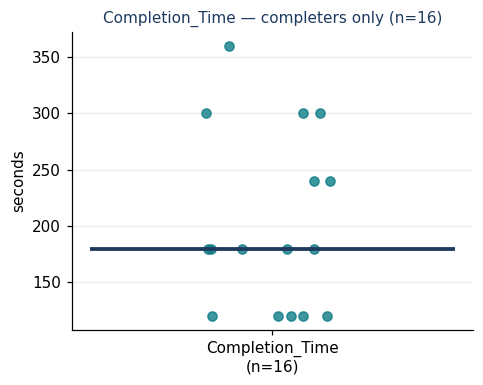

In [12]:
COMPLETED = [COLS["labels"]["unaided"], COLS["labels"]["assisted"]]

def completers(df, time_col):
    """Rows where the task paired with this time column was completed (unaided or assisted)."""
    gate = COLS["times"].get(time_col)
    return df[df[gate].isin(COMPLETED)] if gate else df

rows = [summarise(completers(df, col), col, label=f"{col} (completers only)") for col in COLS["times"]]
rows += [summarise(df, col) for col in COLS["errors"]]
display(pd.DataFrame(rows))

for col in COLS["times"]:
    sub = completers(df, col)
    dot_plot(sub, col, title=f"{col} — completers only (n={len(sub)})", ylabel="seconds")

> ### 📝 Analysis notes — Section 5: Completion Time

**What I see:**  
All 16 participants completed the task. The median completion time was 180 seconds, with a range from 120 to 360 seconds. The mean completion time was 202.5 seconds (SD = 78.6 seconds). Most participants completed the task between 120 and 300 seconds, while one participant took 360 seconds.

**Which committed question this bears on:**  
This bears on the Layer 1.1 usability question by describing how efficiently participants were able to work through the prototype and reach a final travel decision.

**Register — demonstrates / suggests / cannot establish — and why:**  
This **demonstrates** the completion-time distribution for these 16 participants. It **suggests** that most participants were able to complete the task within a relatively short period, but the spread in completion times indicates that some participants required substantially more time than others. It cannot establish that the prototype would produce the same completion times for international students more generally.

**What the interviews need to explain, or what I want to check next:**  
The qualitative data should be checked to understand why some participants took longer than others, especially the participant who required 360 seconds. Relevant explanations may include hesitation, difficulty interpreting disruption information, comparing alternatives, uncertainty about the final decision, or differences in prior public transport experience.

**Deviations from the plan that affect this:**  
No major procedural deviation directly affects the completion-time measure. However, because the sample includes only moderate- and high-frequency public transport users, completion times may partly reflect participants' prior familiarity with public transport rather than the prototype alone.

## 6 · Standardised instruments — SUS and NASA-TLX
Runs whichever you set in `COLS`. **SUS**: report the mean, SD, range and n. 68 is the commonly cited midpoint across many published studies, not a pass mark, and with n = 18 the score is indicative. **NASA-TLX**: report the six sub-scales, not only the raw total — the total hides *which kind* of load.

In [13]:
if COLS.get("sus_prefix"):
    df["sus_score"] = sus_scores(df, prefix=COLS["sus_prefix"])
    display(pd.DataFrame([summarise(df, "sus_score", label="SUS (0–100)")]))
    dot_plot(df, "sus_score", title=f"SUS score — every participant (n={df['sus_score'].notna().sum()})", ylabel="SUS (0–100)")
else:
    print("SUS not used (COLS['sus_prefix'] is None).")

if COLS.get("tlx_prefix"):
    tlx_cols = [c for c in df.columns if c.startswith(COLS["tlx_prefix"])]
    df["tlx_raw"] = tlx_raw(df, prefix=COLS["tlx_prefix"])
    display(pd.DataFrame([summarise(df, c) for c in tlx_cols] + [summarise(df, "tlx_raw", label="Raw TLX (mean of six)")]))
else:
    print("NASA-TLX not used (COLS['tlx_prefix'] is None).")

SUS not used (COLS['sus_prefix'] is None).
NASA-TLX not used (COLS['tlx_prefix'] is None).


## 7 · Single Likert items
A single 1–5 item is **ordinal**: report the count at each point (or the median), not a mean of the numbers.

In [24]:
for col in COLS["likert"]:
    print(f"── {col} ──")
    display(count_table(df, col, order=[1, 2, 3, 4, 5]))
    print(f"median = {pd.to_numeric(df[col], errors='coerce').median()}\n")

── Rating_Disruption_Clarity ──


,count,of_n,percent,report_as
Rating_Disruption_Clarity,,,,
2,1,16,6,1 of 16 (6%)
3,2,16,12,2 of 16 (12%)
4,5,16,31,5 of 16 (31%)
5,8,16,50,8 of 16 (50%)


median = 4.5

── Rating_Compare_Options ──


,count,of_n,percent,report_as
Rating_Compare_Options,,,,
3,2,16,12,2 of 16 (12%)
4,11,16,69,11 of 16 (69%)
5,3,16,19,3 of 16 (19%)


median = 4.0

── Rating_Next_Step_Clarity ──


...

median = 4.0

── PEOU4 ──


,count,of_n,percent,report_as
PEOU4,,,,
3,3,16,19,3 of 16 (19%)
4,7,16,44,7 of 16 (44%)
5,6,16,38,6 of 16 (38%)


median = 4.0

── Confidence ──


,count,of_n,percent,report_as
Confidence,,,,
3,6,16,38,6 of 16 (38%)
4,6,16,38,6 of 16 (38%)
5,4,16,25,4 of 16 (25%)


median = 4.0



> ### 📝 Analysis notes — Sections 6-7: Questionnaire and Likert Evidence

**Information clarity and decision support**  
Fourteen of sixteen participants rated the ease of comparing travel options as 4 or 5, and thirteen of sixteen rated next-step clarity as 4 or 5; both measures had a median of 4. This bears on the evaluation question of whether the prototype helps participants understand the disruption situation and decide what to do next. The register is **suggests**: most participants rated the decision-support process positively, but the ratings alone cannot show which specific information or interface element made the process clear. The interview data should therefore be used to identify which parts of the information supported comparison and action selection, and where participants still experienced hesitation or confusion.

**Perceived usefulness**  
The strongest usefulness result concerned deciding whether the current travel plan needed to change: 9 of 16 participants selected the highest rating of 5, with a median of 5. Understanding how the disruption affected the participant's own journey was also rated strongly, with 8 of 16 selecting 5 and a median of 4.5. The broader usefulness measures remained positive, with medians of 4. This bears on the question of whether the prototype provides meaningful decision support during disruption. The register is **suggests**: the prototype appears to be particularly useful for helping participants judge whether action is necessary, rather than simply presenting disruption information. The interviews should explain what information participants relied on when deciding whether to continue their current journey or change plans.

**Decision confidence**  
Thirteen of sixteen participants rated their overall decision confidence as 4 or 5, with a median of 4. However, the ratings specifically concerning whether the prototype information increased confidence were more dispersed, despite also having a median of 4. This bears on the question of whether the prototype reduces uncertainty and supports confidence in travel decisions. The register is **suggests**: participants were generally confident in their final decisions, but the quantitative results do not establish that this confidence came entirely from the prototype. The interviews should therefore examine whether confidence came from the presented information, prior public transport experience, route familiarity, or knowledge from other transport tools.

**Perceived ease of use**  
All four ease-of-use measures had a median of 4, and most responses were concentrated at 4 or 5. This bears on the evaluation question of whether participants found the prototype understandable and easy to use. The register is **suggests**: participants generally perceived the prototype as learnable, understandable, and manageable to navigate, but this sample contained only moderate- and high-frequency public transport users. Some of the perceived ease may therefore reflect prior familiarity with public transport rather than the interface alone. The qualitative data should be checked for any usability difficulties that were not visible in the positive ratings.

SUS and NASA-TLX were not used in this study, so Section 6 did not produce a standardised usability or workload score. The evidence in this section instead comes from the project-specific quick-evaluation items and the adapted TAM measures, and should be interpreted descriptively for this participant sample.

## 8 · Association — does a characteristic of the person go with an outcome?
This is where the demographics and psychographics you recorded for everyone earn their place. **Before running anything, write in the notes cell below which two or three associations your committed questions care about, and why.** Then run those, report all of them (including the ones that show nothing), and mark anything else as exploratory. Six person-variables against five outcomes is thirty correlations; one or two will look interesting by chance.

The cell draws the **scatterplot first**, then gives **Spearman ρ** (the default — Likert items are ordinal and small samples are rarely normal) and Pearson r, each with n and p. Read the size, not just the sign, and read the plot before the coefficient: at this n one dot can make the line.

> ### 📝 Decided in advance — Section 8 (association)

**Formal Section 8 associations:**  
No formal association was run because the available participant-level background variable, public transport use frequency, is categorical (`Moderate` / `High`) and is more appropriate for the two-group comparison in Section 9.

**Exploratory association:**  
Perceived usefulness against decision confidence — explored to see whether participants who perceived the prototype as more useful also tended to report higher decision confidence. This was not pre-specified as a formal Section 8 association because both variables are outcome measures rather than participant characteristics.

> Anything I run beyond these is **exploratory** and will be labelled as such.

══════ Decision_Confidence against PU_Mean ══════


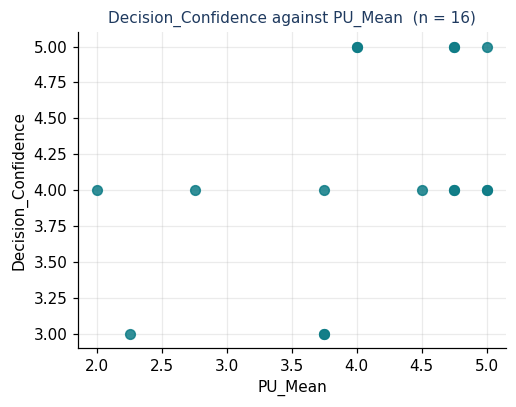

Spearman ρ = 0.46, p = 0.071, n = 16   ← report this one by default
Pearson  r = 0.44, p = 0.086, n = 16   ← only for two continuous, roughly normal measures

Read: a moderate positive association in these 16 participants. Would not conventionally be called
statistically significant. That is a reportable result, not a failure: with n = 16 a correlation
needs to be about 0.50 or larger before p < .05. Report ρ, n and p together. Association is not
cause. Write the sentence in the 'suggests' register and point to the interviews for why.



In [25]:
# ✏️ EDIT: each pair is (person variable, outcome). These should match what you wrote in the cell above.
# Exploratory analysis — not pre-specified
ASSOCIATIONS = [
    ("PU_Mean", "Decision_Confidence"),
]

for x, y in ASSOCIATIONS:
    print(f"══════ {y} against {x} ══════")
    d = completers(df, y) if y in COLS["times"] else df      # times: completers only
    associate(d, x, y)
    print()

> ### 📝 Analysis notes — Section 8 (association)

**Exploratory association — perceived usefulness and decision confidence**

The scatterplot shows a moderate positive pattern between perceived usefulness and decision confidence. Spearman's ρ was 0.46 (n = 16, p = .071). This does not reach the conventional p < .05 threshold, but it suggests that participants who perceived the prototype as more useful also tended to report higher decision confidence.

Because this analysis was exploratory rather than pre-specified, it should not be treated as a confirmatory finding. The association also does not establish causation. The interview data should be used to examine whether higher confidence was related to the prototype's usefulness, prior public transport experience, route familiarity, or other sources of information.

## 9 · Difference — do two kinds of participant differ on an outcome?
Two groups only; nine and nine is the most the sample can stand, and a group of two or three is not a group. If you split a Likert item into two groups, decide the split point **before** you look at the outcome (4–5 versus 1–3, say) and write down why.

The cell shows the per-group descriptives and the two-column dot plot first, then the test: **Mann–Whitney U** for a measured outcome (time, SUS, errors) or **Fisher's exact** for a yes/no outcome (completed or not — give the `success_value`). Report the difference, then the test. A null result is *"no statistically significant difference"* — it is never *"no difference"* or *"the groups performed the same"*.

> ### 📝 Decided in advance — Section 9 (difference)
>**Comparison 1:** Completion time between participants with High and Moderate public transport use frequency — because the evaluation asks whether participants can efficiently interpret disruption information and reach a travel decision, and prior transport familiarity may affect how quickly they complete the task.

>**Comparison 2:** Decision confidence between participants with High and Moderate public transport use frequency — because the evaluation asks whether the prototype supports confident decision-making, and prior public transport familiarity may influence participants' confidence when responding to disruption information.
>
> Anything beyond these is **exploratory**.

══════ Completion_Time by Public_Transport_Use_Frequency ══════
                                n  median  min  max
Public_Transport_Use_Frequency                     
High                            9   240.0  120  360
Moderate                        7   120.0  120  300



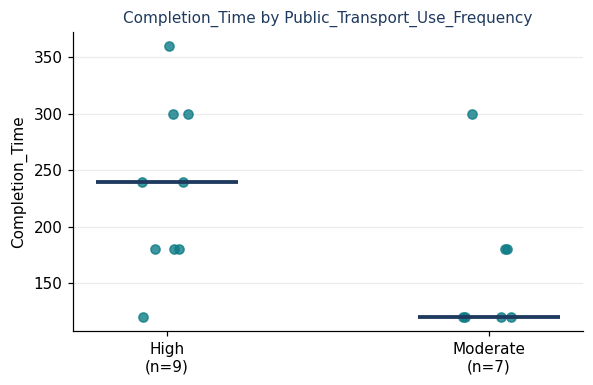

Difference in medians: 240.0 (High, n=9) vs 120.0 (Moderate, n=7)
Mann–Whitney U = 49.0, p = 0.063

Read: there IS an observed difference (say what it is, with the n). The test cannot distinguish it
from chance in groups this small — that is 'no statistically significant difference', which is
honest. It is NOT 'no difference' and NOT 'the groups performed the same'. Say the study was too
small to detect anything but a large effect.

══════ Decision_Confidence by Public_Transport_Use_Frequency ══════
                                n  median  min  max
Public_Transport_Use_Frequency                     
High                            9     4.0    3    5
Moderate                        7     4.0    3    5



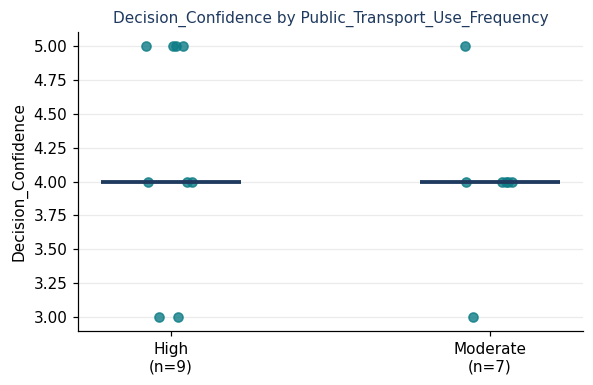

Difference in medians: 4.0 (High, n=9) vs 4.0 (Moderate, n=7)
Mann–Whitney U = 37.5, p = 0.526

Read: there IS an observed difference (say what it is, with the n). The test cannot distinguish it
from chance in groups this small — that is 'no statistically significant difference', which is
honest. It is NOT 'no difference' and NOT 'the groups performed the same'. Say the study was too
small to detect anything but a large effect.



In [26]:
# Example: make a two-level grouping from a Likert item, with the split point stated.  ✏️ EDIT or delete.
#df["confidence_group"] = np.where(pd.to_numeric(df["confidence_tech"], errors="coerce") >= 4, "high (4-5)", "lower (1-3)")

# ✏️ EDIT: each entry is (outcome, grouping column, success_value or None). Match what you wrote above.
COMPARISONS = [
    ("Completion_Time", "Public_Transport_Use_Frequency", None),
    ("Decision_Confidence", "Public_Transport_Use_Frequency", None),
]

for outcome, group, success in COMPARISONS:
    print(f"══════ {outcome} by {group} ══════")
    d = completers(df, outcome) if outcome in COLS["times"] else df
    compare(d, outcome, group, success_value=success)
    print()

> ### 📝 Analysis notes — Section 9: Differences by Public Transport Use Frequency

**Completion time by public transport use frequency**  
Participants with high public transport use frequency (n = 9) had a median completion time of 240 seconds, while participants with moderate use frequency (n = 7) had a median of 120 seconds. The dot plot shows considerable spread within both groups, particularly among the high-frequency users, whose completion times ranged from relatively short to the longest time observed in the dataset. The Mann–Whitney test gave U = 49.0, p = .063.

This bears on the question of whether prior public transport familiarity may influence how efficiently participants interpret disruption information and reach a travel decision. The register is **suggests**: in this sample, high-frequency users actually tended to take longer rather than complete the task faster. However, the test could not distinguish this observed difference from chance at the conventional p < .05 level, and the two groups are small. It therefore cannot establish that public transport use frequency is associated with completion speed.

The qualitative and observational data should be checked to explain why some high-frequency users took longer. One possibility to examine is whether more experienced users considered more alternatives, compared the prototype against their existing knowledge, or questioned the information more carefully rather than simply completing the task faster. The interviews should also help determine whether the longer times reflected difficulty or more deliberate decision-making.

**Decision confidence by public transport use frequency**  
Both groups had a median decision-confidence rating of 4. High-frequency users (n = 9) and moderate-frequency users (n = 7) showed substantial overlap in their ratings, with scores in both groups ranging from 3 to 5. The Mann–Whitney test gave U = 37.5, p = .526.

This bears on the question of whether participants' prior public transport familiarity may contribute to their confidence when making disruption-related travel decisions. The register is **cannot establish**: the current sample provides no clear quantitative evidence that decision confidence differed according to public transport use frequency. This should not be interpreted as evidence that the groups are identical; with only 9 and 7 participants, the study is too small to detect anything other than a relatively large difference.

The interview data should therefore be used to examine where participants said their confidence came from — for example, the prototype information, familiarity with the route, prior public transport experience, or other transport tools. This is particularly important because the earlier questionnaire results suggested that final decision confidence was generally positive even though the extent to which the prototype information itself increased confidence was more variable.

## 10 · Were your interviewees typical of the whole sample?
Your six qualitative participants sit inside the sixteen to twenty. If they were the most confident, or the fastest, or all in one age band, that bounds what the interviews can say — and it is a limitation to write down now, not discover in Week 8. Section 3 showed *who* the six were; this section checks whether they *did* what the others did — the same tasks, the same scores. This is where the two strands touch.

In [27]:
if not COLS.get("interviewed"):
    print("No 'interviewed' column set in COLS — skip this section.")
else:
    iv = COLS["interviewed"]
    check_cols = COLS["person"] + [c for c in ("sus_score",) if c in df.columns] + list(COLS["times"])[:1]   # ✏️ EDIT if you want different columns
    for col in check_cols:
        if col not in df.columns:
            print(f"(no column {col})"); continue
        print(f"── {col} by {iv} ──")
        d = completers(df, col) if col in COLS["times"] else df
        if pd.to_numeric(d[col], errors="coerce").notna().all() and d[col].nunique() > 2:
            display(d.groupby(iv)[col].agg(n="size", median="median", min="min", max="max").round(1))
        else:
            display(pd.crosstab(d[iv], d[col]))
        print()

No 'interviewed' column set in COLS — skip this section.


> ### 📝 Analysis notes —  Section 10: Interviewee Typicality

This comparison is not applicable in this study because all 16 participants completed the qualitative interview component. There is therefore no non-interviewed subgroup against which the interview participants can be compared.

Because the qualitative and quantitative data were collected from the same participant sample, the qualitative findings are not based on a smaller selected subgroup. However, the limitations of the overall participant sample still apply, including the absence of low-frequency public transport users.

## 11 · Bring it together — and keep the evidence
Your notes cells above **are** the analysis/verification checkpoint the Week 7 plan asks for. Three things before you close the session:

**1 · Save this notebook, with your notes, into your Team SharePoint folder.** *File → Download → Download .ipynb*, then upload it to the team folder with today's date in the name (for example `A2_quant_notebook_2026-09-11.ipynb`). Do this at the end of every working session. The notebook with its outputs and notes is your record of what was computed, on what data, and what you made of it — and it is what a tutor can read on Friday. (Your copy in Google Drive is a convenience, not the record.)

**2 · Copy the notes into your collaborative research notebook**, under the analysis section, with a line saying who ran the notebook and on which CSV (file name and date). Add: the error definition you used; what counted as "completed"; and a note that someone other than the person who ran it looked at the outputs and agreed they compute what they claim.

**3 · Save any chart you will use in the report** — right-click the image → *Save image as…* — into the team folder. Every chart used in the report needs one sentence in the notes saying **which committed question it bears on** and whether it *suggests* or *cannot establish*.

**Data hygiene at the end of the session:** *Runtime → Disconnect and delete runtime.* The uploaded CSV is deleted with it. The master copy stays in SharePoint.

> ### 📝 Summary notes — what the numbers say so far
> *Two or three sentences per committed question, in the register you ### 📝 Summary notes — what the numbers say so far

**Committed question 1:**  
The quantitative results suggest that the prototype generally supported independent task completion in this sample. Fifteen of sixteen participants (94%) completed the task unaided, all participants reached a viable final action, and the median completion time was 180 seconds, although times ranged from 120 to 360 seconds.

**Committed question 2:**  
The ratings suggest that participants generally found the prototype clear and usable for comparing options and identifying what to do next. Option comparison and next-step clarity both had a median of 4, while all four ease-of-use measures also had a median of 4, although the quantitative data alone cannot explain where any remaining confusion or hesitation occurred.

**Committed question 3:**  
The results suggest that the prototype provided useful decision support and was associated with generally positive decision confidence. The strongest usefulness evidence concerned helping participants decide whether their travel plan needed to change, with a median of 5, while overall decision confidence had a median of 4; an exploratory association between perceived usefulness and decision confidence showed a moderate positive pattern (Spearman's ρ = 0.46, n = 16, p = .071), but this did not reach the conventional p < .05 threshold.

**Limitations the numbers already show:**  
The sample included only 16 participants and contained only moderate- and high-frequency public transport users, with no low-frequency users represented. All 16 participants completed the interview component, so there was no separate interview subgroup to assess for typicality. In addition, participant characteristics such as age, prior experience with public transport applications, and general device or digital-interface experience were not included in the quantitative dataset. These factors may have influenced completion time, perceived ease of use, perceived usefulness, and decision confidence, but their effects cannot be examined with the current quantitative data.

Public transport use frequency showed an observed difference in completion time (median 240 seconds for High vs 120 seconds for Moderate), but the sample was too small to distinguish this difference from chance (U = 49.0, p = .063). The quantitative findings should therefore be treated as descriptive evidence from this sample and interpreted together with the qualitative and observational data.